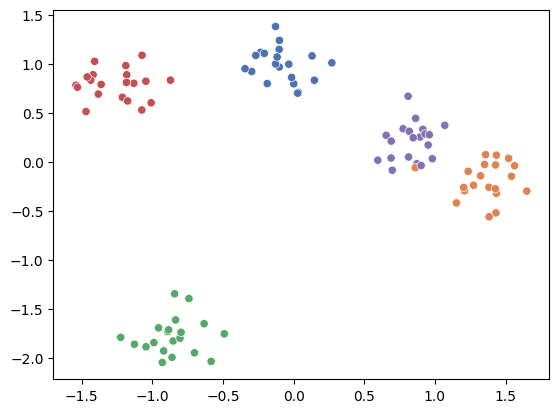

In [75]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = 5
X_train, y = make_blobs(n_samples=100, centers=centers, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x = [point[0] for point in X_train],
    y = [point[1] for point in X_train],
    hue=y,
    palette="deep",
    legend=None
)

plt.show()

In [93]:
import numpy as np
import random

def euclidean(point, data):
    return np.sqrt(np.sum((point-data)**2, axis=1))

class KMeans:
    def __init__(self, n_clusters=8, max_iter=300):
        self.n_clusters = n_clusters
        self.max_iter = max_iter

    def fit(self, X_train):
        # min_, max_ = np.min(X_train, axis=0), np.max(X_train, axis=0)
        # self.centroids = [np.random.uniform(min_, max_) for i in range(self.n_clusters)]
        
        # Improved centroid initialization
        self.centroids = [random.choice(X_train)]

        for _ in range(self.n_clusters-1):
            # Calculate distances from points to the centroids
            dists = np.sum([euclidean(centroid, X_train) for centroid in self.centroids], axis=0)
            # Normalize the distances
            dists /= np.sum(dists)
            # Choose remaining points based on their distances
            new_centroid_idx, = np.random.choice(range(len(X_train)), size=1, p=dists)
            self.centroids += [X_train[new_centroid_idx]]

        iteration = 0
        prev_centroids = None

        while np.not_equal(self.centroids, prev_centroids).any() and iteration < self.max_iter:
            sorted_points = [[] for i in range(self.n_clusters)]
            for point in X_train:
                dists = euclidean(point, self.centroids)
                centroid_idx = np.argmin(dists)
                sorted_points[centroid_idx].append(point)

            prev_centroids = self.centroids
            self.centroids = [np.mean(cluster, axis=0) for cluster in sorted_points]

            for i, centroid in enumerate(self.centroids):
                if np.isnan(centroid).any():
                    self.centroids[i] = prev_centroids[i]
            iteration += 1

    def evaluate(self, X):
        centroids = []
        centroid_idxs = []
        for x in X:
            dists = euclidean(x, self.centroids)
            centroid_idx = np.argmin(dists)
            centroids.append(self.centroids[centroid_idx])
            centroid_idxs.append(centroid_idx)
        return centroids, centroid_idxs

        

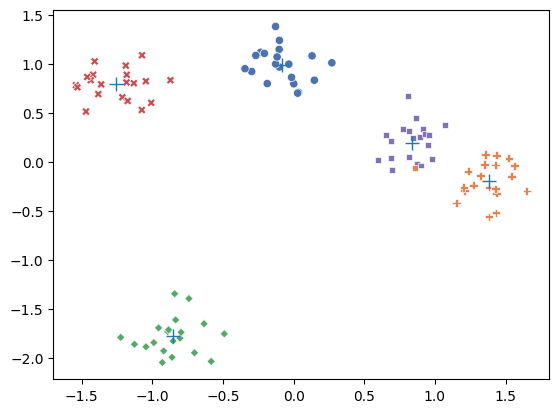

In [98]:
kmeans = KMeans(n_clusters=centers)

kmeans.fit(X_train)

class_centers, classification = kmeans.evaluate(X_train)

sns.scatterplot(
    x=[point[0] for point in X_train],
    y=[point[1] for point in X_train],
    hue=y,
    style=classification,
    palette="deep",
    legend=None
)

plt.plot([x for x, _ in kmeans.centroids],
         [y for _, y in kmeans.centroids],
         "+",
         markersize=10)

plt.show()
